In [2]:
import json
import matplotlib.pyplot as plt

In [3]:
def load_centroids(path, batch_id):
    data = []
    with open(path) as f:
        for line in f:
            record = json.loads(line)
            rid = record.get("batch_id")
            # Accept either int or str
            if rid == batch_id or str(rid) == str(batch_id):
                data = record.get("centroids", [])
                break
    return data

def extract_xy_counts(centroids):
    xs = [c["x"] for c in centroids]
    ys = [c["y"] for c in centroids]
    counts = [c["count"] for c in centroids]
    return xs, ys, counts

def plot_centroids(batch_id, file1, file2, file3):
    data1 = load_centroids(file1, batch_id)
    data2 = load_centroids(file2, batch_id)
    data3 = load_centroids(file3, batch_id)
    x1, y1, cnt1 = extract_xy_counts(data1)
    x2, y2, cnt2 = extract_xy_counts(data2)
    x3, y3, cnt3 = extract_xy_counts(data3)

    plt.figure()
    plt.scatter(x1, y1, s=[c*10 for c in cnt1], label=file1, alpha=0.5)
    plt.scatter(x2, y2, s=[c*10 for c in cnt2], label=file2, alpha=0.5)
    plt.scatter(x3, y3, s=[c*10 for c in cnt3], label=file3, alpha=0.5)
    plt.title(f"Centroids Comparison for Batch {batch_id}")
    plt.xlabel("x")
    plt.ylabel("y")
    # legend in bottom right and make legend circles smaller
    plt.legend(loc='lower left', markerscale=0.25)
    plt.show()

In [4]:
def load_batch(record_file, batch_id):
    with open(record_file) as f:
        for line in f:
            rec = json.loads(line)
            if str(rec.get("batch_id")) == str(batch_id):
                return rec
    raise ValueError(f"Batch {batch_id} not found in {record_file}")

def overlay_centroids(record):
    image = record["image"]  # 2D list
    centroids = record.get("centroids", [])

    xs = [c["x"] for c in centroids]
    ys = [c["y"] for c in centroids]
    sizes = [c["count"] * 10 for c in centroids]  # scale marker sizes

    plt.figure()
    plt.imshow(image)
    plt.scatter(xs, ys, s=sizes, c='red', alpha=0.5, label='Centroids')
    plt.title(f"Batch {record['batch_id']} Overlay: Flink Adjusted Threshold")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

In [5]:
def load_record(file_path, batch_id):
    with open(file_path) as f:
        for line in f:
            rec = json.loads(line)
            if str(rec.get("batch_id")) == str(batch_id):
                return rec
    raise ValueError(f"Batch {batch_id} not found in {file_path}")

def overlay_two_sources(batch_id, file1, file2):
    # Load image and Java centroids from file1
    rec1 = load_record(file1, batch_id)
    image = rec1["image"]
    cents1 = rec1.get("centroids", [])

    # Load Python centroids from file2
    rec2 = load_record(file2, batch_id)
    cents2 = rec2.get("centroids", [])

    # Extract coordinates and sizes
    x1 = [c["x"] for c in cents1]
    y1 = [c["y"] for c in cents1]
    s1 = [c["count"] * 10 for c in cents1]

    x2 = [c["x"] for c in cents2]
    y2 = [c["y"] for c in cents2]
    s2 = [c["count"] * 10 for c in cents2]

    # Plot
    plt.figure()
    plt.imshow(image)
    plt.scatter(x1, y1, s=s1, label="results.json", alpha=0.5)
    plt.scatter(x2, y2, s=s2, label="python_results.json", alpha=0.5)
    plt.title(f"Batch {batch_id}: Java vs Python Centroids")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend(markerscale=0.25)
    plt.show()

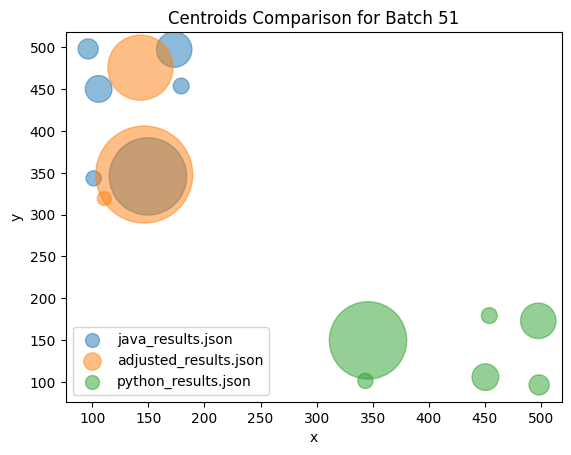

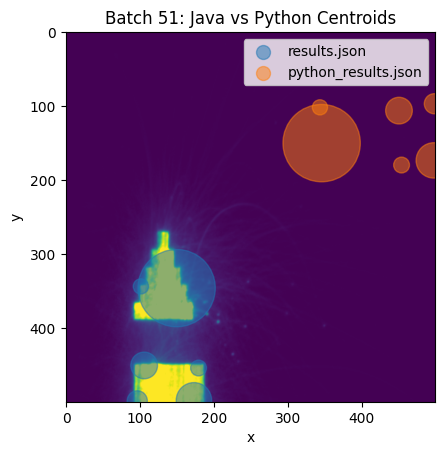

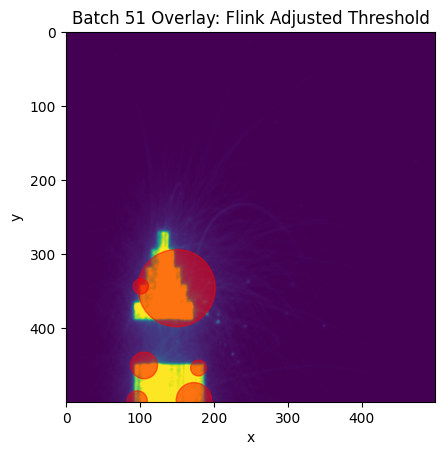

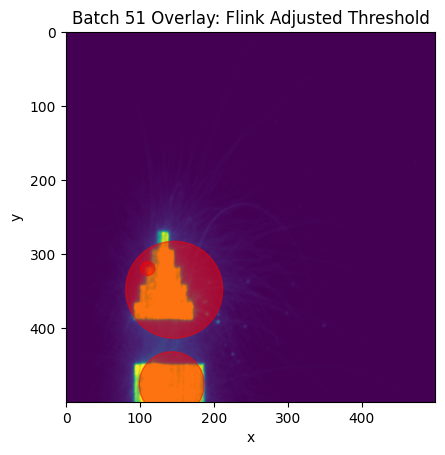

In [7]:
batch_id = 51
plot_centroids(batch_id, "java_results.json", "adjusted_results.json", "python_results.json")
overlay_two_sources(batch_id, "java_results.json", "python_results.json")
# overlay_centroids(load_batch("python_results.json", batch_id))
overlay_centroids(load_batch("java_results.json", batch_id))
overlay_centroids(load_batch("adjusted_results.json", batch_id))

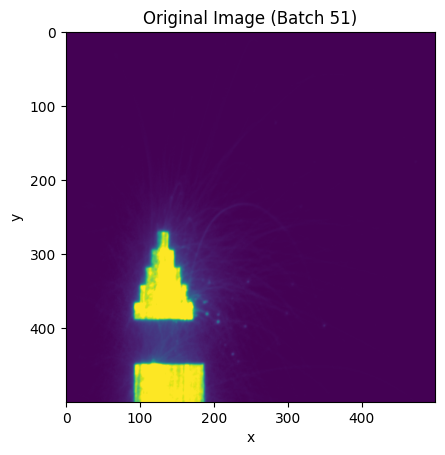

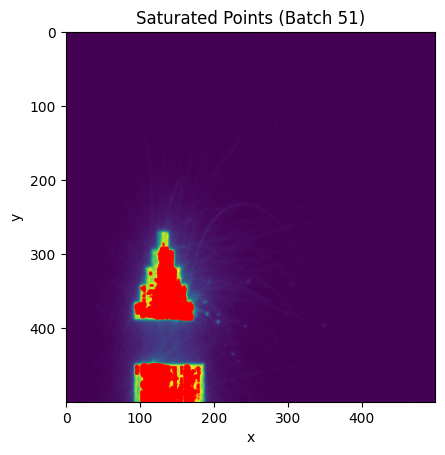

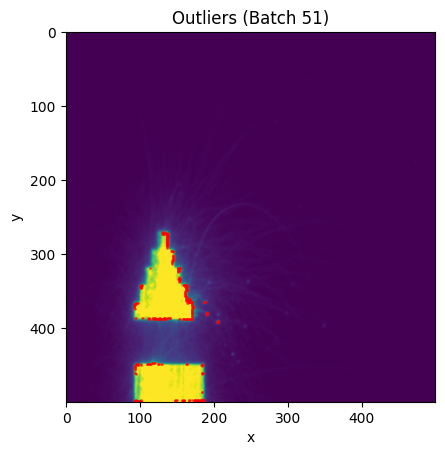

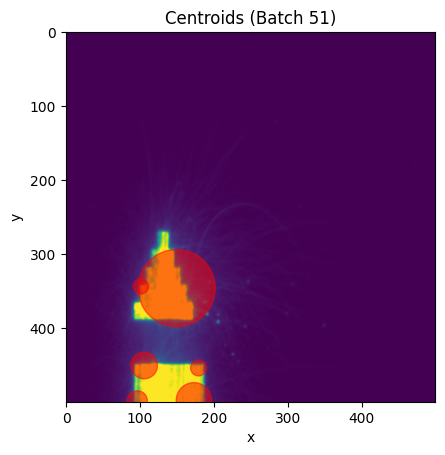

In [89]:
import numpy as np
# Choose batch to visualize
batch_id = 51

# Load data
orig_rec = load_record("results.json", batch_id)
sat_rec = load_record("saturated_points.json", batch_id)
out_rec = load_record("outliers.json", batch_id)
cent_rec = load_record("centroids.json", batch_id)

# Prepare image
image = np.array(orig_rec["image"])

# Prepare saturated points
sat_points = sat_rec.get("saturated_points", [])
sat_rows = [pt[0] for pt in sat_points]
sat_cols = [pt[1] for pt in sat_points]

# Prepare outlier points
outliers = out_rec.get("outliers", [])
out_rows = [pt["row"] for pt in outliers]
out_cols = [pt["col"] for pt in outliers]

# Prepare centroids
centroids = cent_rec.get("centroids", [])
cent_x = [c["x"] for c in centroids]
cent_y = [c["y"] for c in centroids]
cent_sizes = [c["count"] * 10 for c in centroids]

# 1) Original image
plt.figure()
plt.imshow(image)
plt.title(f"Original Image (Batch {batch_id})")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# 2) Saturated points overlay
plt.figure()
plt.imshow(image)
plt.scatter(sat_cols, sat_rows, s=1, c='red', alpha=0.5)
plt.title(f"Saturated Points (Batch {batch_id})")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# 3) Outliers overlay
plt.figure()
plt.imshow(image)
plt.scatter(out_cols, out_rows, s=1, c='red', alpha=0.5)
plt.title(f"Outliers (Batch {batch_id})")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# 4) Centroids overlay
plt.figure()
plt.imshow(image)
plt.scatter(cent_x, cent_y, s=cent_sizes, c='red', alpha=0.5)
plt.title(f"Centroids (Batch {batch_id})")
plt.xlabel("x")
plt.ylabel("y")
plt.show()